<a href="https://colab.research.google.com/github/mabdulrehman8833-cloud/Personal-Projects/blob/main/BBM110L_250451434.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.impute import SimpleImputer

Load data

In [ ]:
# Load data
accidents = pd.read_csv('1_accidents.csv')
vehicles = pd.read_csv('1_vehicles.csv')

merge dataset

In [ ]:
# Merge datasets
df = pd.merge(accidents, vehicles, on='Accident_Index', how='inner')

exploratory analysis

In [ ]:
display(df.info())
display(df.describe())
display(df.notnull().sum())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
Index: 7117 entries, 0 to 7116
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Longitude                     7117 non-null   float64       
 1   Latitude                      7117 non-null   float64       
 2   Accident_Severity             7117 non-null   int64         
 3   Day_of_Week                   7117 non-null   object        
 4   1st_Road_Class                7117 non-null   object        
 5   Speed_limit                   7117 non-null   float64       
 6   Light_Conditions              7117 non-null   object        
 7   Road_Surface_Conditions       7041 non-null   object        
 8   Urban_or_Rural_Area           7117 non-null   object        
 9   High_Winds                    7117 non-null   bool          
 10  Accident_Index                7117 non-null   float64       
 11  Datetime                      7117 

None

,Longitude,Latitude,Accident_Severity,Speed_limit,Accident_Index,Datetime,Age_of_Driver,Engine_Capacity_(CC),Age_of_Vehicle,Hour
count,7117.000000,7117.000000,7117.000000,7117.000000,7117.000000,7117,6224.000000,5512.000000,5275.000000,7117.000000
mean,-1.235565,52.437216,2.791626,36.939391,15177.540537,2024-08-04 11:15:44.310804992,40.575788,1911.195029,9.150721,13.661374
min,-7.266148,50.021069,1.000000,10.187922,7.000000,2024-01-02 00:11:00,0.251049,49.000000,0.015126,0.000000
25%,-2.125354,51.460195,3.000000,28.208232,7446.000000,2024-05-22 14:11:00,26.329192,1242.000000,3.000000,10.000000
50%,-1.122642,52.222880,3.000000,28.884860,15242.000000,2024-08-16 17:45:00,39.400224,1596.000000,7.448817,14.000000
75%,-0.202411,53.180564,3.000000,43.360876,22978.000000,2024-10-24 16:00:00,52.028252,1995.000000,12.000000,18.000000
max,1.740847,59.585172,3.000000,102.404531,29994.000000,2024-12-31 22:41:00,99.160344,19997.000000,225.331947,23.000000
std,1.390317,1.320240,0.432319,14.663303,8784.281946,NaN,17.299858,1809.044927,13.035521,5.215964


,0
Longitude,7117
Latitude,7117
Accident_Severity,7117
Day_of_Week,7117
1st_Road_Class,7117
Speed_limit,7117
Light_Conditions,7117
Road_Surface_Conditions,7041
Urban_or_Rural_Area,7117
High_Winds,7117


,Longitude,Latitude,Accident_Severity,Day_of_Week,1st_Road_Class,Speed_limit,Light_Conditions,Road_Surface_Conditions,Urban_or_Rural_Area,High_Winds,...,Datetime,Towing_and_Articulation,Was_Vehicle_Left_Hand_Drive?,Sex_of_Driver,Age_of_Driver,Engine_Capacity_(CC),Propulsion_Code,Age_of_Vehicle,Driver_Home_Area_Type,Hour
0,0.598546,51.624818,3,Friday,Unclassified,28.862813,Daylight,Dry,Urban,False,...,2024-04-26 09:00:00,No tow/articulation,No,Female,55.000582,1397.0,Heavy oil,2.000000,Urban area,9
1,-0.266532,52.264791,3,Sunday,A,28.951643,Daylight,Dry,Rural,False,...,2024-08-16 18:09:00,No tow/articulation,No,Male,44.690568,2179.0,Heavy oil,NaN,Rural,18
2,-1.273321,51.432416,3,Thursday,Unclassified,67.562446,Daylight,Dry,Urban,False,...,2024-04-05 18:21:00,No tow/articulation,No,Male,44.491347,2143.0,NaN,4.308277,Rural,18
3,-1.145645,51.839400,3,Wednesday,A,57.815491,Daylight,Wet or damp,Rural,False,...,2024-03-26 03:24:00,No tow/articulation,No,Female,22.264466,1598.0,Petrol,1.173413,Urban area,3
4,-1.145645,51.839400,3,Wednesday,A,57.815491,Daylight,Wet or damp,Rural,False,...,2024-03-26 03:24:00,No tow/articulation,No,Female,20.857224,NaN,Petrol,NaN,Rural,3


identify all placeholder values

In [ ]:
display(df['Day_of_Week'].unique())
display(df['1st_Road_Class'].unique())
display(df['Road_Surface_Conditions'].unique())
display(df['Light_Conditions'].unique())
display(df['Urban_or_Rural_Area'].unique())
display(df['Towing_and_Articulation'].unique())
display(df['Was_Vehicle_Left_Hand_Drive?'].unique())
display(df['Propulsion_Code'].unique())
display(df['Driver_Home_Area_Type'].unique())

array(['Friday', 'Sunday', 'Thursday', 'Wednesday', 'Tuesday', 'Monday',
       'Saturday'], dtype=object)

array(['Unclassified', 'A', 'B', 'Motorway', 'C', 'A(M)'], dtype=object)

array(['Dry', 'Wet or damp', 'Snow', 'Data missing or out of range',
       'Frost or ice', 'Flood over 3cm. deep'], dtype=object)

array(['Daylight', 'Darkness - lights lit', 'Darkness - no lighting',
       'Darkness - lighting unknown', 'Darkness - lights unlit'],
      dtype=object)

array(['Urban', 'Rural'], dtype=object)

array(['No tow/articulation', 'Data missing or out of range',
       'Articulated vehicle', 'Other tow', 'Single trailer', 'Caravan',
       'Double or multiple trailer'], dtype=object)

array(['No', 'Yes', 'Data missing or out of range'], dtype=object)

array(['Heavy oil', 'Undefined', 'Petrol', 'Hybrid electric',
       'Petrol/Gas (LPG)', 'Gas/Bi-fuel', 'Electric', 'Gas',
       'Electric diesel'], dtype=object)

array(['Urban area', 'Rural', 'Data missing or out of range',
       'Small town'], dtype=object)

drop rows with na index rows with placeholder values

In [ ]:
df = df.dropna(subset=['Accident_Index'])

# Identify and replace missing value placeholders
placeholders = [-1, -1.0, 'Data missing or out of range', 'Not known', 'Undefined']
df.replace(placeholders, np.nan, inplace=True)

print(f"Merged Dataset Shape: {df.shape}")
print("Target Variable Distribution:")
print(df['Accident_Severity'].value_counts(normalize=True))

display(df.info())
display(df.describe())

Merged Dataset Shape: (7117, 20)
Target Variable Distribution:
Accident_Severity
3    0.802585
2    0.186455
1    0.010960
Name: proportion, dtype: float64
<class 'pandas.core.frame.DataFrame'>
Index: 7117 entries, 0 to 7116
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Longitude                     7117 non-null   float64
 1   Latitude                      7117 non-null   float64
 2   Accident_Severity             7117 non-null   int64  
 3   Day_of_Week                   7117 non-null   object 
 4   1st_Road_Class                7117 non-null   object 
 5   Speed_limit                   7117 non-null   float64
 6   Light_Conditions              7117 non-null   object 
 7   Road_Surface_Conditions       7041 non-null   object 
 8   Urban_or_Rural_Area           7117 non-null   object 
 9   High_Winds                    7117 non-null   bool   
 10  Accident_Index               

None

,Longitude,Latitude,Accident_Severity,Speed_limit,Accident_Index,Age_of_Driver,Engine_Capacity_(CC),Age_of_Vehicle
count,7117.000000,7117.000000,7117.000000,7117.000000,7117.000000,6224.000000,5512.000000,5275.000000
mean,-1.235565,52.437216,2.791626,36.939391,15177.540537,40.575788,1911.195029,9.150721
std,1.390317,1.320240,0.432319,14.663303,8784.281946,17.299858,1809.044927,13.035521
min,-7.266148,50.021069,1.000000,10.187922,7.000000,0.251049,49.000000,0.015126
25%,-2.125354,51.460195,3.000000,28.208232,7446.000000,26.329192,1242.000000,3.000000
50%,-1.122642,52.222880,3.000000,28.884860,15242.000000,39.400224,1596.000000,7.448817
75%,-0.202411,53.180564,3.000000,43.360876,22978.000000,52.028252,1995.000000,12.000000
max,1.740847,59.585172,3.000000,102.404531,29994.000000,99.160344,19997.000000,225.331947


define features for the algorithm and get hour from datetime column.

In [ ]:
# Feature Engineering: Extract Hour from Datetime
df['Datetime'] = pd.to_datetime(df['Datetime'])
df['Hour'] = df['Datetime'].dt.hour

# Select features for modeling
features = [
    'Day_of_Week', '1st_Road_Class', 'Speed_limit', 'Light_Conditions',
    'Road_Surface_Conditions', 'Urban_or_Rural_Area', 'High_Winds',
    'Towing_and_Articulation', 'Was_Vehicle_Left_Hand_Drive?', 'Sex_of_Driver',
    'Age_of_Driver', 'Engine_Capacity_(CC)', 'Propulsion_Code', 'Age_of_Vehicle',
    'Driver_Home_Area_Type', 'Hour'
]
X = df[features].copy()
y = df['Accident_Severity']

Imput missing values. Detect and remove outliers. Cap data. Encode using labelencoder.

In [ ]:
# 1. Missing Value Imputation
cat_cols = X.select_dtypes(include=['object', 'bool']).columns
num_cols = X.select_dtypes(include=['number']).columns

imputer_cat = SimpleImputer(strategy='most_frequent')
X[cat_cols] = imputer_cat.fit_transform(X[cat_cols])

imputer_num = SimpleImputer(strategy='median')
X[num_cols] = imputer_num.fit_transform(X[num_cols])

# 2. Outlier Detection and Capping (99th percentile)
for col in ['Age_of_Vehicle', 'Engine_Capacity_(CC)', 'Speed_limit']:
    upper_limit = X[col].quantile(0.99)
    X[col] = np.where(X[col] > upper_limit, upper_limit, X[col])

# 3. Encoding
X_le = X.copy()
for col in cat_cols:
    le = LabelEncoder()
    X_le[col] = le.fit_transform(X_le[col].astype(str))

# One-hot encoding for the Baseline (Logistic Regression)
X_oh = pd.get_dummies(X, columns=cat_cols)

# Split data
X_train_le, X_test_le, y_train, y_test = train_test_split(X_le, y, test_size=0.2, random_state=42, stratify=y)
X_train_oh, X_test_oh, _, _ = train_test_split(X_oh, y, test_size=0.2, random_state=42, stratify=y)

# Scaling (required for Logistic Regression)
scaler = StandardScaler()
X_train_oh_scaled = scaler.fit_transform(X_train_oh)
X_test_oh_scaled = scaler.transform(X_test_oh)

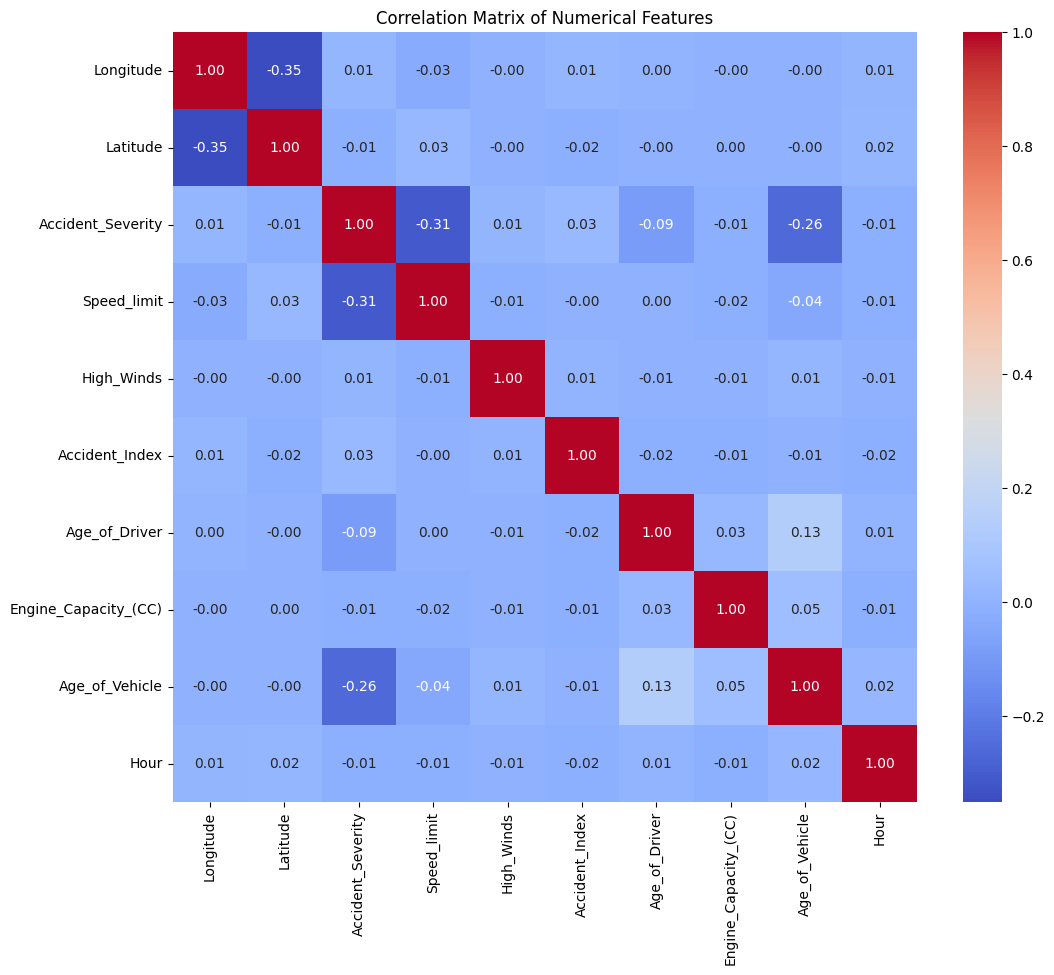

In [ ]:
# 1. Select only numerical and boolean columns
# This excludes strings like 'Friday' and avoids the conversion error.
numeric_df = df.select_dtypes(include=['number', 'bool'])

# 2. Calculate the correlation matrix
corr_matrix2 = numeric_df.corr()

# 3. Visualize with a heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix2, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [ ]:
baseline = LogisticRegression(max_iter=1000, multi_class='multinomial', class_weight='balanced', random_state=42)
baseline.fit(X_train_oh_scaled, y_train)
y_pred_base = baseline.predict(X_test_oh_scaled)

print("--- Baseline Model (Logistic Regression) ---")
print(classification_report(y_test, y_pred_base))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


--- Baseline Model (Logistic Regression) ---
              precision    recall  f1-score   support

           1       0.03      0.31      0.05        16
           2       0.42      0.48      0.45       265
           3       0.91      0.76      0.83      1143

    accuracy                           0.70      1424
   macro avg       0.45      0.52      0.44      1424
weighted avg       0.81      0.70      0.75      1424



In [ ]:
# Model 1: Random Forest with Tuning
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
rf_search = RandomizedSearchCV(RandomForestClassifier(class_weight='balanced', random_state=42),
                               rf_param_grid, n_iter=5, cv=3, random_state=42)
rf_search.fit(X_train_le, y_train)
best_rf = rf_search.best_estimator_

# Model 2: Gradient Boosting with Tuning
gb_param_grid = {
    'n_estimators': [100, 150],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}
gb_search = RandomizedSearchCV(GradientBoostingClassifier(random_state=42),
                               gb_param_grid, n_iter=5, cv=3, random_state=42)
gb_search.fit(X_train_le, y_train)
best_gb = gb_search.best_estimator_

# Evaluation
print("\n--- Model 1: Tuned Random Forest ---")
print(classification_report(y_test, best_rf.predict(X_test_le)))

print("\n--- Model 2: Tuned Gradient Boosting ---")
print(classification_report(y_test, best_gb.predict(X_test_le)))


--- Model 1: Tuned Random Forest ---
              precision    recall  f1-score   support

           1       1.00      0.06      0.12        16
           2       0.84      0.81      0.83       265
           3       0.96      0.98      0.97      1143

    accuracy                           0.94      1424
   macro avg       0.93      0.62      0.64      1424
weighted avg       0.94      0.94      0.93      1424


--- Model 2: Tuned Gradient Boosting ---
              precision    recall  f1-score   support

           1       0.57      0.25      0.35        16
           2       0.88      0.93      0.91       265
           3       0.98      0.98      0.98      1143

    accuracy                           0.96      1424
   macro avg       0.81      0.72      0.75      1424
weighted avg       0.96      0.96      0.96      1424



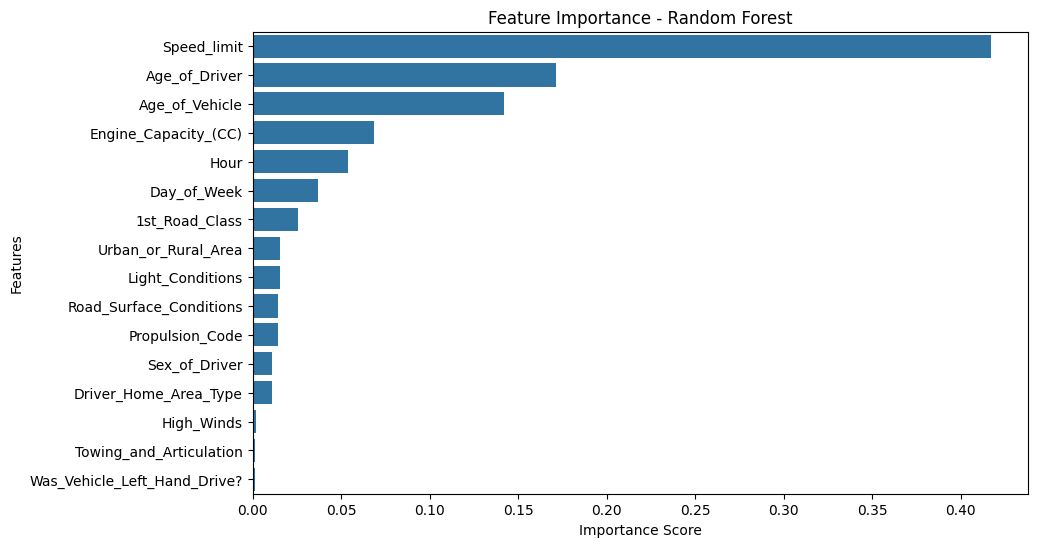

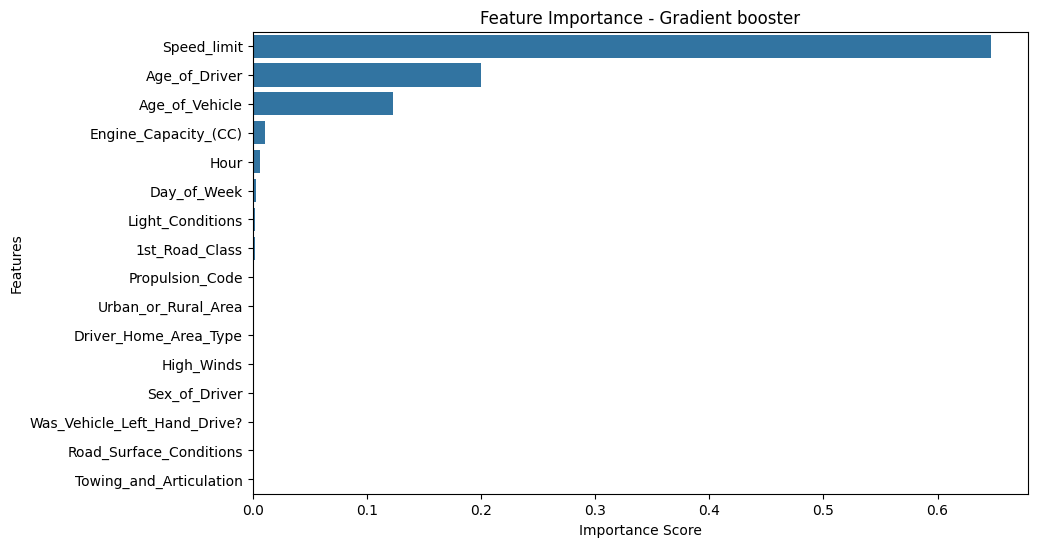

In [ ]:
# Plot Feature Importance from Random Forest
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=np.array(features)[indices])
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.savefig('feature_importance.png')

# Plot Feature Importance from Random Forest
importances = best_gb.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=np.array(features)[indices])
plt.title("Feature Importance - Gradient booster")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.savefig('feature_importance.png')

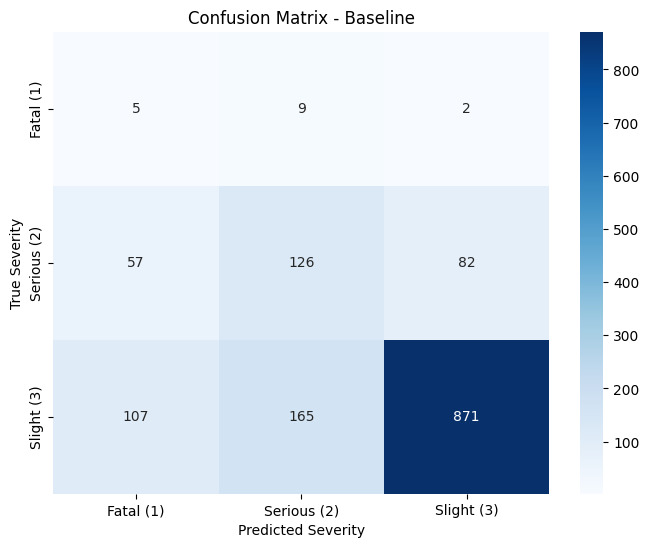

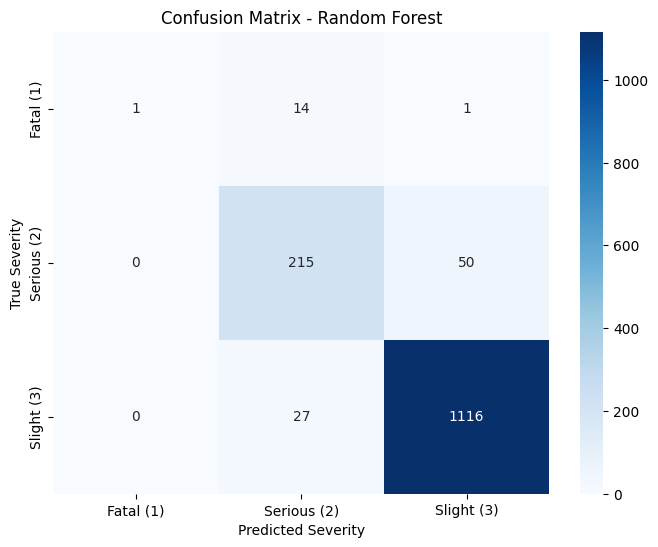

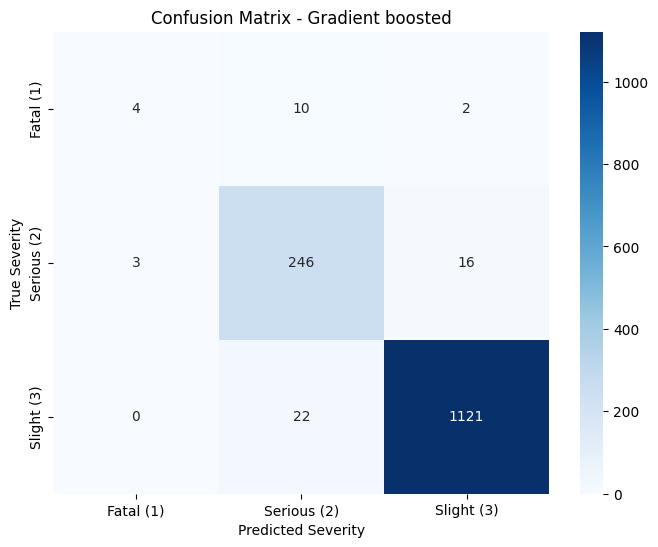

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Labels for the matrix
labels = ['Fatal (1)', 'Serious (2)', 'Slight (3)']

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.ylabel('True Severity')
    plt.xlabel('Predicted Severity')
    plt.show()

plot_confusion_matrix(y_test, y_pred_base, 'Confusion Matrix - Baseline')
plot_confusion_matrix(y_test, best_rf.predict(X_test_le), 'Confusion Matrix - Random Forest')
plot_confusion_matrix(y_test, best_gb.predict(X_test_le), 'Confusion Matrix - Gradient boosted')

***